# E-commerce Negative Margin Analysis

Business problem: The company has a negative margin in e-commerce. Stakeholders want to know how many SKUs have a negative margin, how much loss they make, and why.

Data source: AI generated data (20 SKUs)

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

## Check the data

In [2]:
df_preview = duckdb.query("SELECT * FROM 'data/raw_sales.csv' LIMIT 5").to_df()
print(df_preview)

  product_id   category             product_line total_sales total_cogs  \
0   SKU-1001   Footwear     Performance Sneakers    $124,500   $142,000   
1   SKU-1002   Footwear      Trail Running Shoes     $98,200   $105,000   
2   SKU-1003   Footwear         Lifestyle Canvas    $210,000   $160,000   
3   SKU-1004  Outerwear       Heavy Winter Parka    $185,000   $202,000   
4   SKU-1005  Outerwear  Lightweight Windbreaker    $142,000   $130,000   

  return_logistics_cost  
0               $10,800  
1                $7,400  
2                $8,500  
3               $15,200  
4                $5,100  


In [3]:
check_query = """
SELECT 
    COUNT(*) AS total_rows,
    COUNT(DISTINCT product_id) AS unique_skus,
    SUM(CASE WHEN total_sales IS NULL THEN 1 ELSE 0 END) AS null_sales,
    SUM(CASE WHEN total_cogs IS NULL THEN 1 ELSE 0 END) AS null_cogs,
    SUM(CASE WHEN return_logistics_cost IS NULL THEN 1 ELSE 0 END) AS null_return_cost
FROM 'data/raw_sales.csv';
"""

print(duckdb.query(check_query).to_df())

   total_rows  unique_skus  null_sales  null_cogs  null_return_cost
0          20           20         0.0        0.0               0.0


## Clean the data

The money columns are text like "$124,500", so I removed $ and , and changed them to numbers.

In [4]:
clean_query = """
CREATE OR REPLACE VIEW clean_sales AS
SELECT 
    category,
    product_line,
    product_id,
    CAST(REPLACE(REPLACE(total_sales, '$', ''), ',', '') AS DOUBLE) AS total_sales,
    CAST(REPLACE(REPLACE(total_cogs, '$', ''), ',', '') AS DOUBLE) AS total_cogs,
    CAST(REPLACE(REPLACE(return_logistics_cost, '$', ''), ',', '') AS DOUBLE) AS return_logistics_cost
FROM 'data/raw_sales.csv';
"""

duckdb.query(clean_query)

## Overall numbers

In [5]:
summary_query = """
SELECT 
    COUNT(*) AS total_skus,
    SUM(CASE WHEN total_cogs + return_logistics_cost > total_sales THEN 1 ELSE 0 END) AS loss_skus,
    SUM(total_sales) AS total_sales,
    SUM(total_sales - total_cogs - return_logistics_cost) AS overall_profit
FROM clean_sales;
"""

df_summary = duckdb.query(summary_query).to_df()
print(df_summary)

   total_skus  loss_skus  total_sales  overall_profit
0          20       12.0    2689100.0        -21400.0


## Negative margin SKUs

I split the loss into 2 parts:
- price_gap: how much the product cost (COGS) is higher than the sales
- return_logistics_cost: return and shipping cost

In [6]:
analysis_query = """
SELECT 
    category,
    product_line,
    total_sales,
    total_cogs - total_sales AS price_gap,
    return_logistics_cost,
    total_cogs + return_logistics_cost - total_sales AS loss_amount,
    ROUND((total_sales - total_cogs - return_logistics_cost) / total_sales * 100, 1) AS margin_pct
FROM clean_sales
WHERE (total_cogs + return_logistics_cost) > total_sales
ORDER BY loss_amount DESC;
"""

df_loss = duckdb.query(analysis_query).to_df()
print("--- [SQL Result] ---")
print(df_loss)

total_loss = df_loss['loss_amount'].sum()
total_skus = len(df_loss)
print(f"Total Loss Amount: ${total_loss:,.0f}")
print(f"Total Loss SKUs: {total_skus}")

--- [SQL Result] ---
       category           product_line  total_sales  price_gap  \
0     Outerwear     Heavy Winter Parka     185000.0    17000.0   
1      Footwear   Performance Sneakers     124500.0    17500.0   
2     Equipment      Travel Duffel 50L     122000.0    13000.0   
3       Apparel   Merino Wool Crewneck     156000.0    12000.0   
4       Apparel    Alpaca Knit Sweater     112000.0    13000.0   
5     Equipment   Daypack Backpack 25L     168000.0    11000.0   
6   Accessories  Leather Crossbody Bag     134000.0    11000.0   
7     Sleepwear     Thermal Base Layer     105000.0     9000.0   
8     Outerwear            Puffer Vest      88400.0     7600.0   
9      Footwear    Trail Running Shoes      98200.0     6800.0   
10  Accessories     Merino Wool Beanie      76000.0     6500.0   
11    Sleepwear    Fleece Lounge Pants      89000.0     3000.0   

    return_logistics_cost  loss_amount  margin_pct  
0                 15200.0      32200.0       -17.4  
1             

In [7]:
# how many SKUs lose money even before returns?
below_cost = (df_loss['price_gap'] > 0).sum()
print(f"SKUs with COGS higher than sales: {below_cost} of {total_skus}")

# how much of the loss comes from price vs returns
price_share = df_loss['price_gap'].sum() / total_loss
print(f"Loss from price gap: {price_share:.0%}")
print(f"Loss from returns and logistics: {1 - price_share:.0%}")

# top 3 SKUs
top3_share = df_loss['loss_amount'].head(3).sum() / total_loss
print(f"Top 3 SKUs share of loss: {top3_share:.0%}")

SKUs with COGS higher than sales: 12 of 12
Loss from price gap: 56%
Loss from returns and logistics: 44%
Top 3 SKUs share of loss: 36%


## Chart

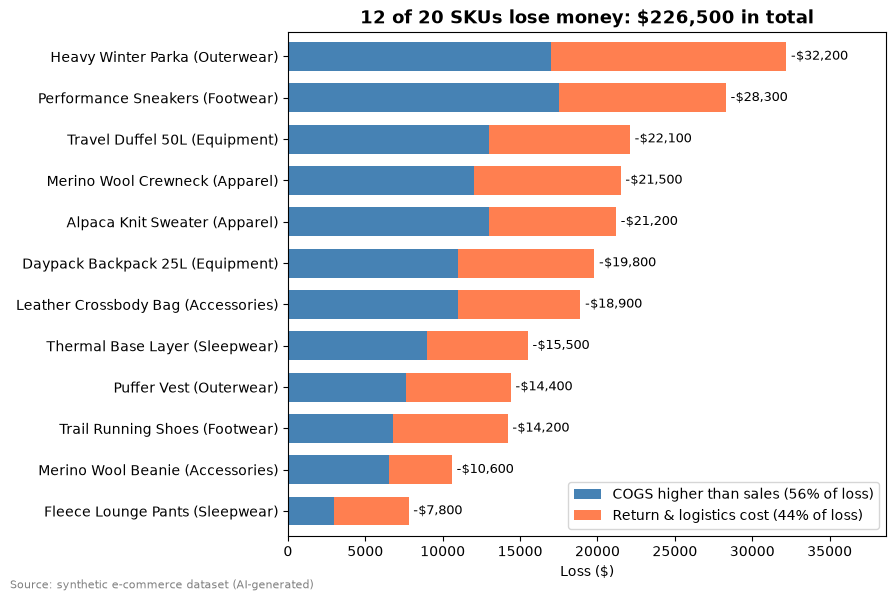

In [8]:
chart_df = df_loss.sort_values('loss_amount')
chart_df['label'] = chart_df['product_line'] + ' (' + chart_df['category'] + ')'
chart_df = chart_df.set_index('label')

ax = chart_df[['price_gap', 'return_logistics_cost']].plot(
    kind='barh',
    stacked=True,
    figsize=(9, 6),
    color=['steelblue', 'coral'],
    width=0.7
)

for i, value in enumerate(chart_df['loss_amount']):
    ax.text(value + 300, i, f'-${value:,.0f}', va='center', fontsize=9)

plt.title(f'{total_skus} of 20 SKUs lose money: ${total_loss:,.0f} in total', fontsize=13, fontweight='bold')
plt.xlabel('Loss ($)')
plt.ylabel('')
plt.legend([f'COGS higher than sales ({price_share:.0%} of loss)', f'Return & logistics cost ({1 - price_share:.0%} of loss)'], loc='lower right')
plt.xlim(0, chart_df['loss_amount'].max() * 1.2)
plt.figtext(0.01, 0.01, 'Source: synthetic e-commerce dataset (AI-generated)', fontsize=8, color='gray')
plt.tight_layout()

plt.savefig('chart_result.png', dpi=300)
plt.show()

## Insight

- 12 of 20 SKUs (60%) have a negative margin. Total loss is $226,500.
- Because of this loss, the whole business is -$21,400 on $2.69M sales.
- All 12 SKUs have COGS higher than the sales price, so they lose money even before returns.
- 56% of the loss is from the price gap and 44% is from returns and logistics.
- The biggest losses are Heavy Winter Parka (-$32,200) and Performance Sneakers (-$28,300).

## Recommendation

1. Increase the price or negotiate lower COGS with suppliers. Start with the top 3 SKUs (36% of the loss).
2. Reduce return costs for items with high returns, like Heavy Winter Parka.
3. Stop selling SKUs that can't reach break-even.

At first I thought promotion could help, but selling more of these products would make the loss bigger because each one is sold below cost.